In [62]:
from finches.forcefields.mpipi import Mpipi_model
from finches.forcefields.calvados import calvados_model
from finches.epsilon_calculation import InteractionMatrixConstructor
import numpy as np
import matplotlib.pyplot as plt
import goose

In [2]:
def frobenius_norm(A):
    """
    Calculate the Frobenius norm of a matrix A.
    """
    fro_norm = np.sqrt(np.sum(np.square(A)))
    return A / fro_norm

def row_norm(A):
    row_norms = np.linalg.norm(A, ord=2, axis=1, keepdims=True)

    X_normalized = A / (row_norms)

    return X_normalized

In [3]:
Mpipi_GGv1_params = Mpipi_model(version = 'Mpipi_GGv1')
Mpipi_GGv1_params_20mM = Mpipi_model(version = 'Mpipi_GGv1', salt=20)
calvados_params = calvados_model(version = 'CALVADOS2')

In [4]:
IMC_mpipi = InteractionMatrixConstructor(parameters = Mpipi_GGv1_params)
IMC_mpipi_20mM = InteractionMatrixConstructor(parameters = Mpipi_GGv1_params_20mM)
IMC_calvados = InteractionMatrixConstructor(parameters = calvados_params)

In [5]:
# sequence = 'ADFGERTGNKRWQWQWQWP'
sequence = goose.create.sequence(length=150)

In [6]:
mpipi_interactions = IMC_mpipi.calculate_pairwise_homotypic_matrix(sequence)
mpipi_interactions_20mM = IMC_mpipi_20mM.calculate_pairwise_homotypic_matrix(sequence)
calvados_interactions = IMC_calvados.calculate_pairwise_homotypic_matrix(sequence)

In [7]:
mpipi_interactions = mpipi_interactions.copy()
calvados_interactions = calvados_interactions.copy()
mpipi_interactions_20mM = mpipi_interactions_20mM.copy()

# Zero out the diagonals properly
np.fill_diagonal(mpipi_interactions, 0)
np.fill_diagonal(calvados_interactions, 0)
np.fill_diagonal(mpipi_interactions_20mM, 0)

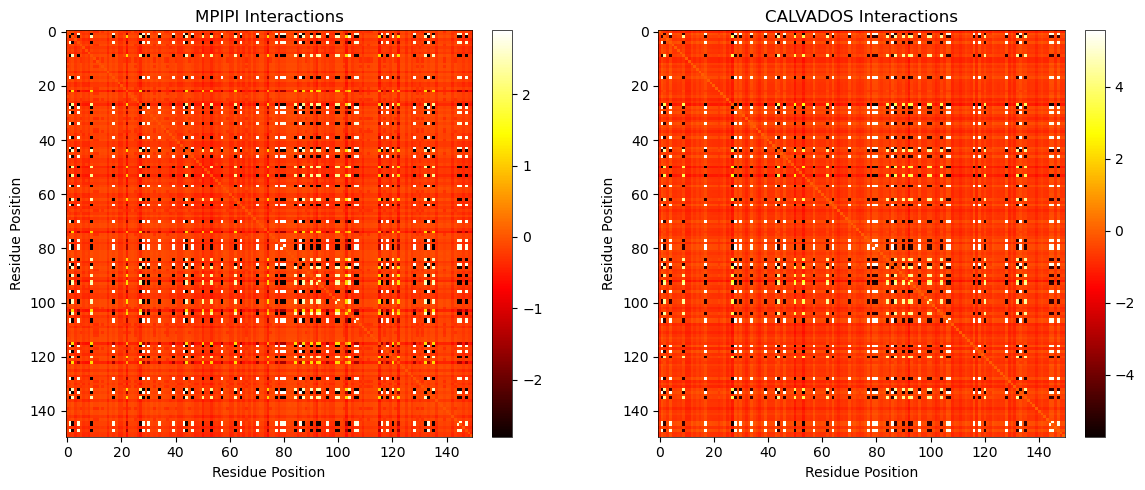

In [8]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(mpipi_interactions, cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(calvados_interactions, cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

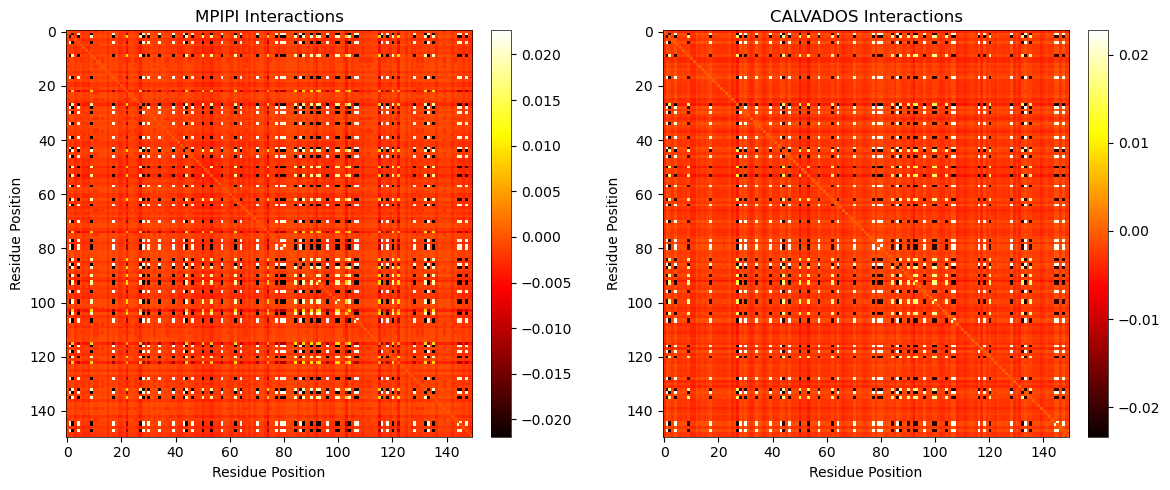

In [10]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(frobenius_norm(mpipi_interactions), cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(frobenius_norm(calvados_interactions), cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

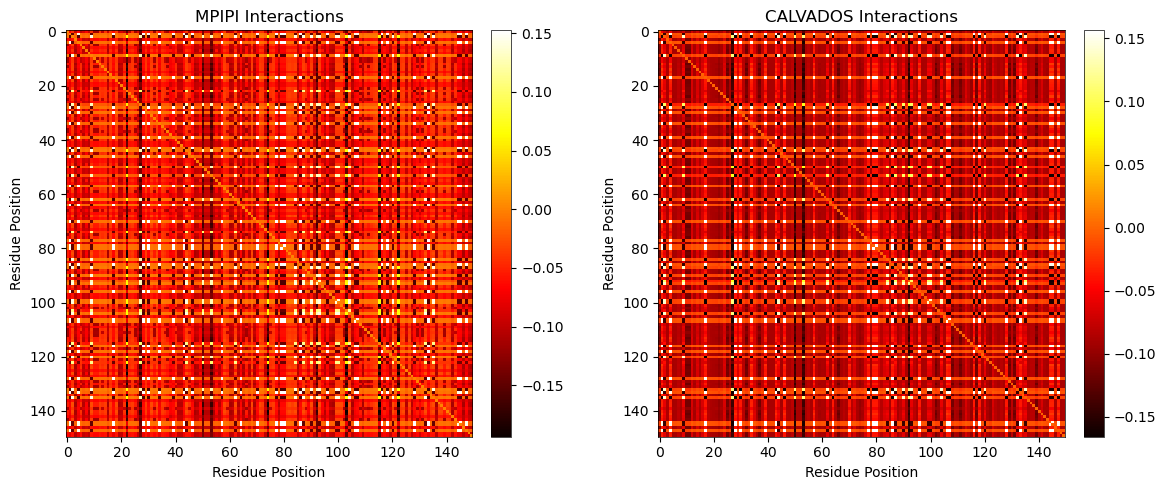

In [11]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(row_norm(mpipi_interactions), cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(row_norm(calvados_interactions), cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [21]:
fro_norm = np.linalg.norm(mpipi_interactions, ord='fro')

In [23]:
sequence[:10]

'GEKQESNPQK'

In [19]:
mpipi_interactions[1][:10]

array([-0.19279018,  0.        , -2.70886767, -0.32912168,  2.65805009,
       -0.17169015, -0.31307952, -0.25888997, -0.32912168, -2.70886767])

In [20]:
calvados_interactions[1][:10]

array([-0.56998551,  0.        , -4.95333655, -0.2882101 ,  5.29920366,
       -0.34397742, -0.31685979, -0.24039927, -0.2882101 , -4.95333655])

In [21]:
row_norm(mpipi_interactions)[1][:10]

array([-0.01052692,  0.        , -0.14791227, -0.01797103,  0.14513747,
       -0.00937479, -0.01709508, -0.01413617, -0.01797103, -0.14791227])

In [22]:
row_norm(calvados_interactions)[1][:10]

array([-0.01640544,  0.        , -0.14256794, -0.00829532,  0.15252276,
       -0.00990043, -0.00911992, -0.00691922, -0.00829532, -0.14256794])

In [59]:
import h5py

In [60]:
def load_hdf5(filename):
    """
    Load an HDF5 file and return the data.
    """
    with h5py.File(filename, 'r') as f:
        data = {}
        for key in f.keys():
            data[key] = f[key][()]
    return data

In [61]:
ls /work/bnovak/projects/sequence2ensemble/lammps_data/20mM_data/mPIPIgg_20mM/

A0A087WTH5_1_132.h5*
A0A087WTH5_1_132_vae_encoded.h5*
A0A087WVF3_214_549.h5*
A0A087WVF3_214_549_vae_encoded.h5*
A0A087WXM9_1_373.h5*
A0A087WXM9_1_373_vae_encoded.h5*
A0A087X179_214_549.h5*
A0A087X179_214_549_vae_encoded.h5*
A0A096LP49_1_317.h5*
A0A096LP49_1_317_vae_encoded.h5*
A0A096LP49_318_634.h5*
A0A096LP49_318_634_vae_encoded.h5*
A0A096LP49_681_1063.h5*
A0A096LP49_681_1063_vae_encoded.h5*
A0A0J9YXQ4_85_350.h5*
A0A0J9YXQ4_85_350_vae_encoded.h5*
A0A0J9YY54_151_432.h5*
A0A0J9YY54_151_432_vae_encoded.h5*
A0A0J9YY54_433_714.h5*
A0A0J9YY54_433_714_vae_encoded.h5*
A0A0U1RRE5_1_68.h5*
A0A0U1RRE5_1_68_vae_encoded.h5*
A0A0U1RRN3_1_59.h5*
A0A0U1RRN3_1_59_vae_encoded.h5*
A0A1B0GTC6_1_90.h5*
A0A1B0GTC6_1_90_vae_encoded.h5*
A0A1B0GTK5_1_79.h5*
A0A1B0GTK5_1_79_vae_encoded.h5*
A0A1B0GTR3_1_108.h5*
A0A1B0GTR3_1_108_vae_encoded.h5*
A0A1B0GTS1_188_333.h5*
A0A1B0GTS1_188_333_vae_encoded.h5*
A0A1B0GTU1_450_805.h5*
A0A1B0GTU1_450_805_vae_encoded.h5*
A0A1B0GTU1_94_449.h5*
A0A1B0GTU1_94_449_vae_encoded.h5

In [63]:
data20mM = load_hdf5('/work/bnovak/projects/sequence2ensemble/lammps_data/20mM_data/mPIPIgg_20mM/Y5I6C8Q8C3_vae_encoded.h5')
data300mM = load_hdf5('/work/bnovak/projects/sequence2ensemble/lammps_data/300mM_data/mPIPIgg_300mM/Y5I6C8Q8C3_vae_encoded.h5')

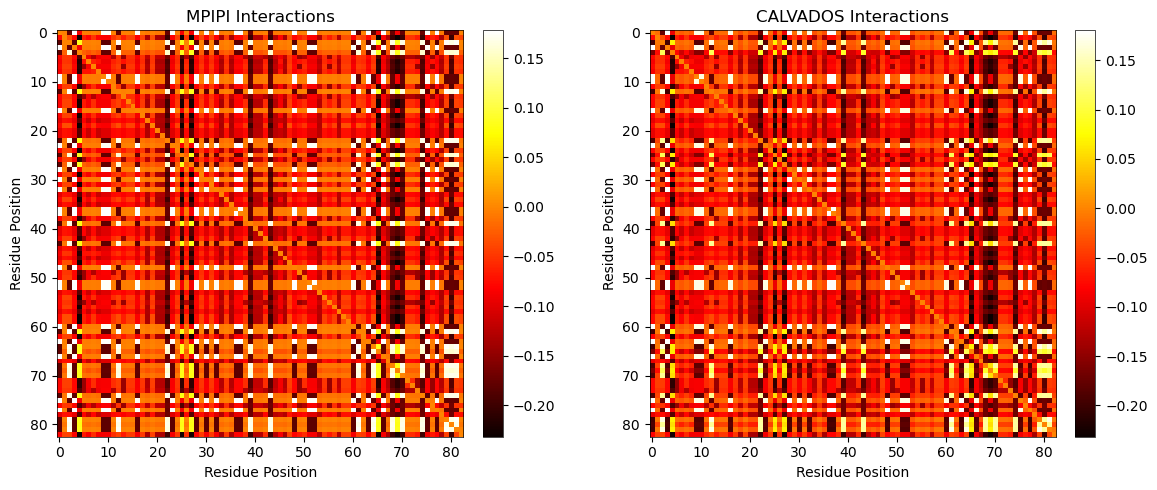

In [69]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(data20mM['finches_row_norm'], cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(data300mM['finches_row_norm'], cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [70]:
from starling.data.tokenizer import StarlingTokenizer
mpipi_interactions = IMC_mpipi.calculate_pairwise_homotypic_matrix(StarlingTokenizer().decode(data300mM['seq']))
mpipi_interactions = mpipi_interactions.copy()
np.fill_diagonal(mpipi_interactions, 0)

In [80]:
data20mM['finches_row_norm'][0]

array([ 0.        , -0.00368348, -0.17605487,  0.1779541 , -0.08927422,
       -0.00489375, -0.00656596, -0.0043301 , -0.00656596,  0.17497257,
        0.17497257, -0.0043301 , -0.17605487, -0.00489375, -0.00396673,
       -0.00396673,  0.17497257, -0.00396673, -0.0085096 , -0.00368348,
       -0.0085096 , -0.0085096 , -0.17491455,  0.17497257, -0.00396673,
       -0.08927422, -0.0043301 , -0.08927422,  0.1779541 , -0.00396673,
        0.17497257, -0.00396673,  0.17497257, -0.0085096 , -0.00396673,
       -0.0085096 ,  0.1779541 ,  0.1779541 , -0.0043301 , -0.17491455,
       -0.00808276, -0.00808276, -0.0043301 , -0.17491455, -0.00808276,
       -0.00656596, -0.0085096 , -0.00368348,  0.1779541 , -0.00489375,
       -0.0043301 ,  0.17497257,  0.17497257, -0.00808276, -0.00396673,
       -0.00489375, -0.00396673, -0.00808276, -0.00368348, -0.00368348,
        0.17497257, -0.17605487, -0.00396673,  0.1779541 , -0.17605487,
       -0.08927422,  0.17497257, -0.0085096 , -0.17491455, -0.08

In [73]:
row_norm(mpipi_interactions)[0]

array([ 0.        , -0.00840543, -0.17503478,  0.18092473, -0.0905931 ,
       -0.01116718, -0.01498303, -0.00988096, -0.01498303,  0.17336025,
        0.17336025, -0.00988096, -0.17503478, -0.01116718, -0.00905178,
       -0.00905178,  0.17336025, -0.00905178, -0.01941828, -0.00840543,
       -0.01941828, -0.01941828, -0.17206258,  0.17336025, -0.00905178,
       -0.0905931 , -0.00988096, -0.0905931 ,  0.18092473, -0.00905178,
        0.17336025, -0.00905178,  0.17336025, -0.01941828, -0.00905178,
       -0.01941828,  0.18092473,  0.18092473, -0.00988096, -0.17206258,
       -0.01844427, -0.01844427, -0.00988096, -0.17206258, -0.01844427,
       -0.01498303, -0.01941828, -0.00840543,  0.18092473, -0.01116718,
       -0.00988096,  0.17336025,  0.17336025, -0.01844427, -0.00905178,
       -0.01116718, -0.00905178, -0.01844427, -0.00840543, -0.00840543,
        0.17336025, -0.17503478, -0.00905178,  0.18092473, -0.17503478,
       -0.0905931 ,  0.17336025, -0.01941828, -0.17206258, -0.09

In [74]:
data300mM['finches_row_norm'][0]

array([ 0.        , -0.01398408, -0.1752915 ,  0.18048537, -0.09186825,
       -0.0185788 , -0.02492723, -0.01643893, -0.02492723,  0.16985059,
        0.16985059, -0.01643893, -0.1752915 , -0.0185788 , -0.01505942,
       -0.01505942,  0.16985059, -0.01505942, -0.03230613, -0.01398408,
       -0.03230613, -0.03230613, -0.17131643,  0.16985059, -0.01505942,
       -0.09186825, -0.01643893, -0.09186825,  0.18048537, -0.01505942,
        0.16985059, -0.01505942,  0.16985059, -0.03230613, -0.01505942,
       -0.03230613,  0.18048537,  0.18048537, -0.01643893, -0.17131643,
       -0.03068567, -0.03068567, -0.01643893, -0.17131643, -0.03068567,
       -0.02492723, -0.03230613, -0.01398408,  0.18048537, -0.0185788 ,
       -0.01643893,  0.16985059,  0.16985059, -0.03068567, -0.01505942,
       -0.0185788 , -0.01505942, -0.03068567, -0.01398408, -0.01398408,
        0.16985059, -0.1752915 , -0.01505942,  0.18048537, -0.1752915 ,
       -0.09186825,  0.16985059, -0.03230613, -0.17131643, -0.09